In [2]:
import pandas as pd

In [3]:
file_path = "NUS Project/BeijingHousingPrices (2011-2017).xlsx"
df = pd.read_excel(file_path, sheet_name="new")

In [4]:
#Show column types
print("\nData Types:")
print(df.dtypes)


Data Types:
url                            object
id                             object
Lng                           float64
Lat                           float64
Cid                             int64
tradeTime              datetime64[ns]
DOM                           float64
followers                       int64
totalPrice                    float64
price                           int64
square                        float64
livingRoom                    float64
drawingRoom                    object
kitchen                         int64
bathRoom                       object
floor                          object
buildingType                  float64
constructionTime               object
renovationCondition             int64
buildingStructure               int64
ladderRatio                   float64
elevator                      float64
fiveYearsProperty             float64
subway                        float64
district                        int64
communityAverage              float64

In [5]:
#Step 3: Clean the data

#Clean tradeTime + Convert tradeTime to datetime and extract tradeYear
df['tradeTime'] = pd.to_datetime(df['tradeTime'], errors='coerce')
df = df.dropna(subset=['tradeTime'])
df['tradeYear'] = df['tradeTime'].dt.year   #extract trade year 

#Clean constructionTime
df = df[df['constructionTime'].apply(lambda x: str(x).isdigit())]
df['constructionTime'] = df['constructionTime'].astype(int)

#Clean square
df = df.dropna(subset=['square'])
df = df[df['square'] > 0]

#Filter for transaction years only (2011–2017)
df = df[(df['tradeYear'] >= 2011) & (df['tradeYear'] <= 2017)]

#Define Age Group based on construction year
def classify_age(year):
    return "Old (< 2005)" if year < 2005 else "New (≥ 2005)"
df['ageGroup'] = df['constructionTime'].apply(classify_age)

#Calculate pricePerSqm
df['pricePerSqm'] = df['totalPrice'] * 10000 / df['square']

#Group by tradeYear and ageGroup
grouped = df.groupby(['tradeYear', 'ageGroup'])['pricePerSqm'].mean().reset_index()

ageGroup,New (≥ 2005),Old (< 2005)
tradeYear,,
2011,21123.911479,21808.433547
2012,24440.177803,26452.494977
2013,31988.767797,36213.974932
2014,33760.323187,38307.180949
2015,35451.450741,40409.060754
2016,46328.339885,52834.361627
2017,60441.295627,70954.090406


ageGroup
New (≥ 2005)    186.13
Old (< 2005)    225.35
dtype: float64

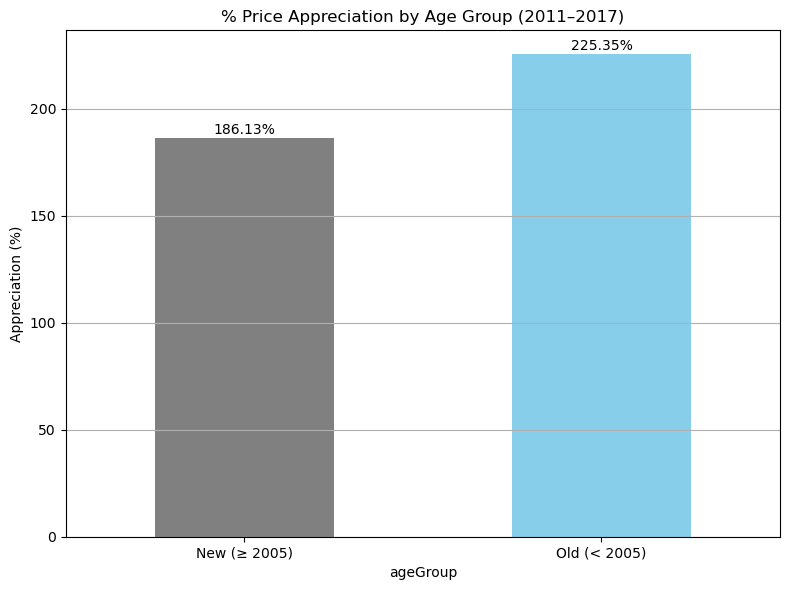

In [6]:
#Create pivot table
pivot = grouped.pivot(index='tradeYear', columns='ageGroup', values='pricePerSqm')
pivot = pivot.dropna()   #remove years w missing values
display(pivot)

import matplotlib.pyplot as plt
#Calculate Appreciation from 2011 to 2017
first_year = pivot.index.min()
last_year = pivot.index.max()

first = pivot.loc[first_year]
last = pivot.loc[last_year]

appreciation = ((last - first) / first * 100).round(2)
display(appreciation)

#Plot
plt.figure(figsize=(8, 6))
appreciation.plot(kind='bar', color=['gray', 'skyblue'])

plt.title(f"% Price Appreciation by Age Group (2011–2017)")
plt.ylabel("Appreciation (%)")
plt.xticks(rotation=0)
plt.grid(axis='y')
plt.tight_layout()

#Add values on bars
for i, val in enumerate(appreciation):
    plt.text(i, val + 2, f"{val}%", ha='center', fontsize=10)

plt.show()

In [7]:
#Show missing values
print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))


Missing Values:
DOM                    146144
buildingType             1544
communityAverage          295
subway                     20
fiveYearsProperty          20
elevator                   20
livingRoom                 20
url                         0
ageGroup                    0
tradeYear                   0
district                    0
ladderRatio                 0
buildingStructure           0
renovationCondition         0
constructionTime            0
bathRoom                    0
floor                       0
id                          0
kitchen                     0
drawingRoom                 0
square                      0
price                       0
totalPrice                  0
followers                   0
tradeTime                   0
Cid                         0
Lat                         0
Lng                         0
pricePerSqm                 0
dtype: int64


In [8]:
#Drop missing or invalid values
df = df.dropna(subset=['totalPrice', 'square', 'fiveYearsProperty'])

#Filter out zero or negative square meters
df = df[df['square'] > 0]

In [9]:
#Show missing values
print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))


Missing Values:
DOM                    146137
buildingType             1544
communityAverage          295
url                         0
floor                       0
ageGroup                    0
tradeYear                   0
district                    0
subway                      0
fiveYearsProperty           0
elevator                    0
ladderRatio                 0
buildingStructure           0
renovationCondition         0
constructionTime            0
bathRoom                    0
id                          0
kitchen                     0
drawingRoom                 0
livingRoom                  0
square                      0
price                       0
totalPrice                  0
followers                   0
tradeTime                   0
Cid                         0
Lat                         0
Lng                         0
pricePerSqm                 0
dtype: int64


In [10]:
df['Eligibility'] = df['fiveYearsProperty'].map({1: 'Eligible', 0: 'Not Eligible'})
df[['Eligibility', 'pricePerSqm']]

,Eligibility,pricePerSqm
0,Not Eligible,31679.389313
1,Eligible,43435.564285
2,Not Eligible,52020.202020
3,Not Eligible,22201.492537
4,Eligible,48395.061728
...,...,...
318845,Eligible,26490.312966
318846,Eligible,20579.761275
318847,Not Eligible,31005.984611
318848,Eligible,35137.515905


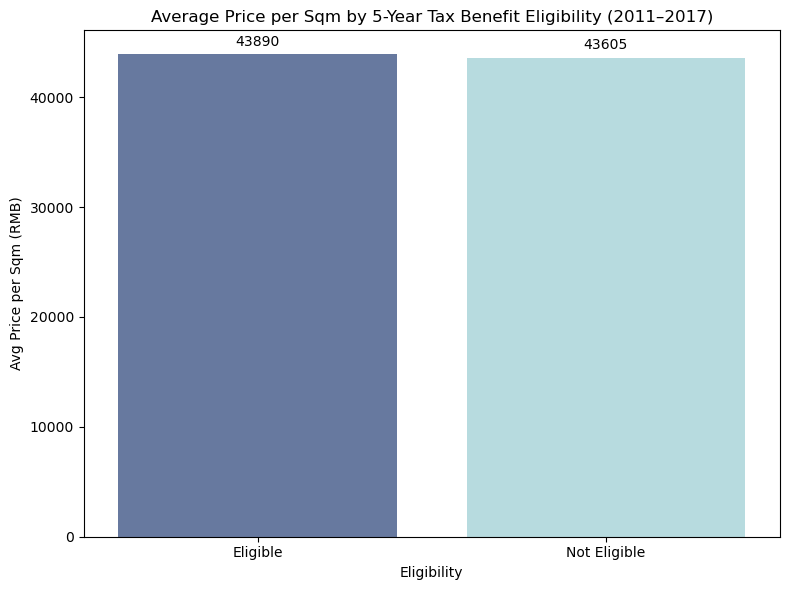

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare summary data
grouped = df.groupby('Eligibility')['pricePerSqm'].mean().round(2).reset_index()

# Plot bar chart with hue and no legend
plt.figure(figsize=(8,6))
#ax = sns.barplot(data=grouped, x='Eligibility', y='pricePerSqm', hue='Eligibility',  palette=['#1f77b4', '#ff7f0e'], legend=False)

palette = {
    'Eligible': '#5D76A9',      #powder blue 
    'Not Eligible': '#B0E0E6'   # red
}
ax = sns.barplot(data=grouped, x='Eligibility', y='pricePerSqm', hue='Eligibility',
                 palette=palette, legend=False)

# Add labels on top
for index, row in grouped.iterrows():
    ax.text(index, row['pricePerSqm'] + 500, f"{row['pricePerSqm']:.0f}", 
            ha='center', va='bottom', fontsize=10)

# Final labels and layout
plt.title("Average Price per Sqm by 5-Year Tax Benefit Eligibility (2011–2017)")
plt.ylabel("Avg Price per Sqm (RMB)")
plt.xlabel("Eligibility")
plt.tight_layout()
plt.show()

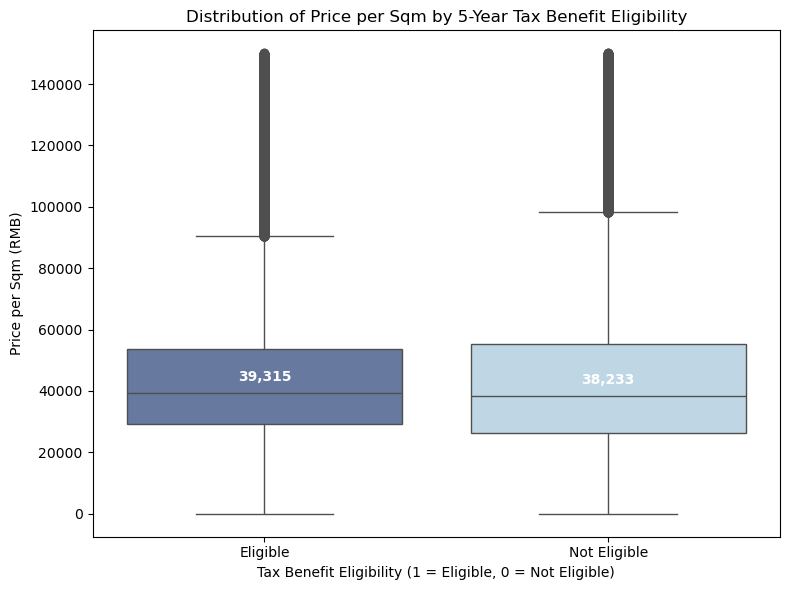

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the desired order for x-axis categories
order = ['Eligible', 'Not Eligible']

# Calculate median price per group (same order)
median_values = df.groupby('Eligibility')['pricePerSqm'].median().reindex(order).reset_index()

# Plot boxplot with defined order
plt.figure(figsize=(8, 6))
ax = sns.boxplot(data=df, x='Eligibility', y='pricePerSqm', hue='Eligibility',
                 palette=['#5D76A9', '#B9D9EB'], 
                 order=order, hue_order=order,
                 legend=False)

# Add median labels
for i, row in median_values.iterrows():
    ax.text(i, row['pricePerSqm'] + 3000,
            f"{int(row['pricePerSqm']):,}",
            ha='center', va='bottom', fontweight='bold', color='white')

# Final touches
plt.title("Distribution of Price per Sqm by 5-Year Tax Benefit Eligibility")
plt.ylabel("Price per Sqm (RMB)")
plt.xlabel("Tax Benefit Eligibility (1 = Eligible, 0 = Not Eligible)")
plt.tight_layout()
plt.show()
